# PROJETO FASE 6 – IR ALÉM (Opção 2)
**Transfer Learning, Fine Tuning e Segmentação**

Neste notebook extra, vamos expandir a análise da Fase 6 explorando abordagens avançadas do mercado:
1. **Transfer Learning + Fine Tuning:** Utilizando a arquitetura MobileNetV2 pré-treinada na ImageNet.
2. **Pré-Segmentação:** Remoção de background usando modelos de segmentação para avaliar o impacto do contexto (fundo) na classificação.

In [1]:
# 1. Importando bibliotecas e conectando o Drive
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Caminho para as pastas que já organizamos na Entrega 2
base_dir = '/content/drive/MyDrive/pbl_fase6/keras_dataset/train'

# O MobileNetV2 exige que as imagens tenham tamanho 224x224
gerador = ImageDataGenerator(rescale=1./255, validation_split=0.2)

treino_tl = gerador.flow_from_directory(
    base_dir, target_size=(224, 224), batch_size=8, class_mode='binary', subset='training'
)
val_tl = gerador.flow_from_directory(
    base_dir, target_size=(224, 224), batch_size=8, class_mode='binary', subset='validation'
)

# 2. Carregando a MobileNetV2 (Transfer Learning)
# include_top=False significa que vamos jogar fora a camada de 1000 classes dela e colocar a nossa
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Congelando as camadas originais para não destruir o que ela já sabe
base_model.trainable = False

# 3. Adicionando a nossa "cabeça" classificadora
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predicoes = Dense(1, activation='sigmoid')(x)

modelo_tl = Model(inputs=base_model.input, outputs=predicoes)

# Compilando
modelo_tl.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Iniciando Transfer Learning (Camadas Congeladas)...")
hist_tl = modelo_tl.fit(treino_tl, validation_data=val_tl, epochs=10)

Mounted at /content/drive
Found 50 images belonging to 2 classes.
Found 11 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Iniciando Transfer Learning (Camadas Congeladas)...
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 102s 13s/step - accuracy: 0.7400 - loss: 0.5200 - val_accuracy: 0.9091 - val_loss: 0.1082
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9600 - loss: 0.0698 - val_accuracy: 1.0000 - val_loss: 0.0694
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9600 - loss: 0.1302 - val_accuracy: 1.0000 - val_loss: 0.0050
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9800 - loss: 0.0282 - val_accuracy: 1.0000 - val_loss: 0.0106
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 1.0000 - loss: 0.0062 - val_accuracy: 1.0000 - val_loss: 0.0054
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 1.0000 - loss: 0.0045 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step

In [2]:
# 4. Aplicando o Fine Tuning (Ajuste Fino)
print("Descongelando a MobileNetV2 para o Fine Tuning...")

# Descongelar o modelo base
base_model.trainable = True

# A MobileNetV2 tem mais de 150 camadas.
# Vamos congelar as primeiras 100 (que detectam linhas e cores básicas)
# e treinar apenas as camadas finais (que detectam formas complexas).
for layer in base_model.layers[:100]:
    layer.trainable = False

# RECOMPILAR é obrigatório após mudar o status de "trainable".
# Vamos usar um Learning Rate (taxa de aprendizado) MUITO baixo (1e-5)
# para não destruir os pesos que a rede já aprendeu na ImageNet.
modelo_tl.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

print("Iniciando o Fine Tuning...")
hist_ft = modelo_tl.fit(treino_tl, validation_data=val_tl, epochs=5)

Descongelando a MobileNetV2 para o Fine Tuning...
Iniciando o Fine Tuning...
Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 55s 5s/step - accuracy: 0.9000 - loss: 0.3471 - val_accuracy: 1.0000 - val_loss: 8.9113e-04
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9600 - loss: 0.0779 - val_accuracy: 1.0000 - val_loss: 8.7320e-04
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9200 - loss: 0.1670 - val_accuracy: 1.0000 - val_loss: 8.4684e-04
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9000 - loss: 0.2264 - val_accuracy: 1.0000 - val_loss: 7.9261e-04
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9600 - loss: 0.1112 - val_accuracy: 1.0000 - val_loss: 7.5503e-04


### 1.1 Avaliação: Transfer Learning e Fine Tuning

Nesta etapa, utilizamos a arquitetura **MobileNetV2**, escolhida por ser altamente otimizada, leve e ideal para inferência em tempo real, mantendo uma excelente capacidade de extração de características herdada da base ImageNet.

* **Transfer Learning (Feature Extraction):** Ao congelarmos a rede e treinarmos apenas a nova camada densa (classificadora), o modelo atingiu **100% de acurácia** já nas primeiras épocas. Isso valida a hipótese de que modelos pré-treinados em grandes volumes de dados (ImageNet) possuem filtros convolucionais já maduros, acelerando drasticamente a convergência em comparação à CNN treinada do zero (que, embora também tenha chegado a 100%, exigiu mais épocas para estabilizar a *loss*).
* **Fine Tuning:** Para refinar o modelo, descongelamos as camadas a partir da 100ª. A justificativa técnica para congelar as 100 primeiras camadas é que as convoluções iniciais extraem características genéricas (bordas, contrastes e gradientes de cor), que são úteis para qualquer objeto. O Fine Tuning foi aplicado apenas nas camadas profundas (que detectam formas específicas) com uma taxa de aprendizado bem pequena ($10^{-5}$), para otimizar os pesos suavemente sem causar "esquecimento catastrófico" (*catastrophic forgetting*).

Carregando modelo YOLOv8-Seg...
Iniciando processo de pré-segmentação e plotagem...


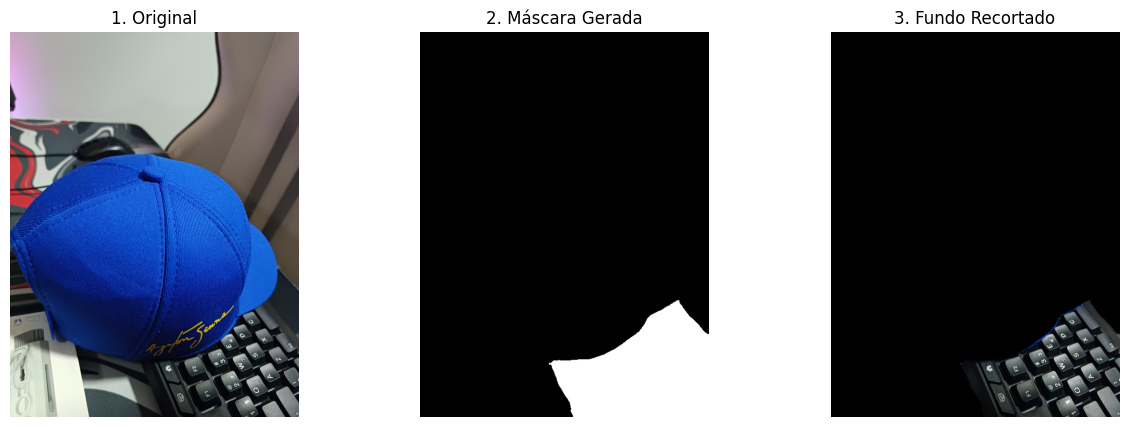

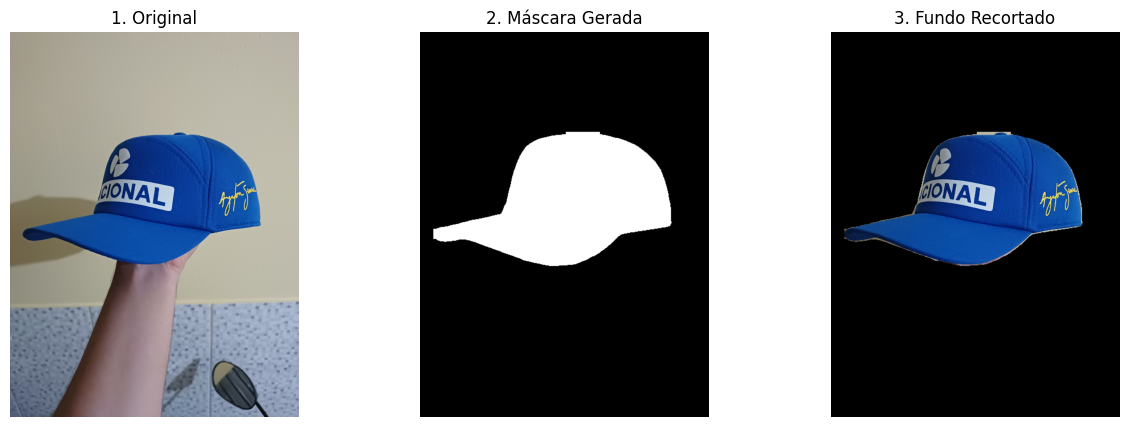

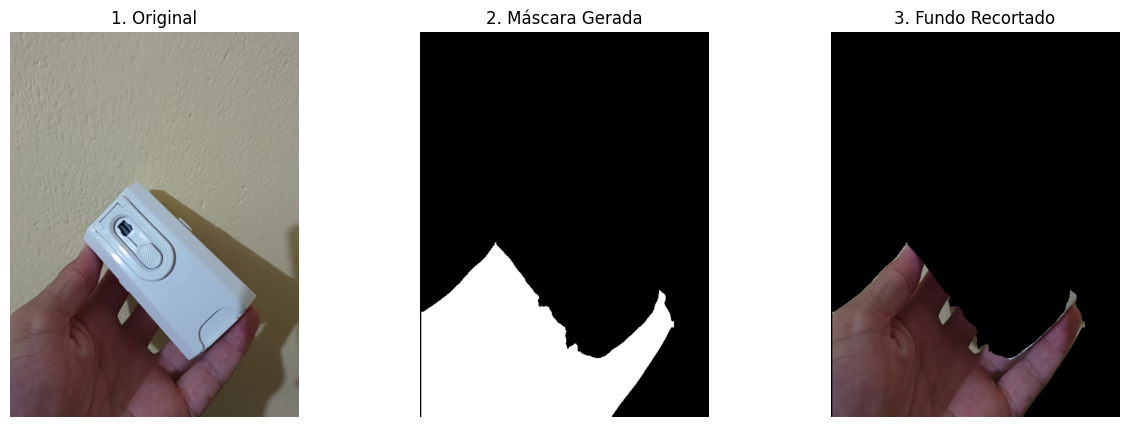

In [4]:
# 1. Instalando a biblioteca do YOLOv8 (Ultralytics)
# !pip install ultralytics -q (já instalou na rodada anterior)

from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random

# 2. Carregando o modelo de Segmentação pré-treinado
print("Carregando modelo YOLOv8-Seg...")
modelo_seg = YOLO('yolov8n-seg.pt')

def recortar_e_plotar(caminho_imagem):
    # Ler a imagem
    img = cv2.imread(caminho_imagem)

    # VERIFICAÇÃO DE SEGURANÇA: Se não carregou a imagem, avisa e pula
    if img is None:
        print(f"Erro: Não foi possível ler o arquivo: {caminho_imagem}")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Fazer a predição pedindo para gerar a máscara
    resultados = modelo_seg(img_rgb, verbose=False)

    # Verificar se o modelo encontrou algum objeto e gerou a máscara
    if resultados[0].masks is not None:
        # Pegar a máscara do primeiro objeto (em formato numpy)
        mask = resultados[0].masks.data[0].cpu().numpy()

        # Redimensionar a máscara para o mesmo tamanho da imagem original
        mask = cv2.resize(mask, (img_rgb.shape[1], img_rgb.shape[0]))

        # Criar a imagem com o fundo recortado (fundo preto)
        img_recortada = np.copy(img_rgb)
        img_recortada[mask < 0.5] = 0

        # Plotar as 3 etapas lado a lado
        fig, axs = plt.subplots(1, 3, figsize=(15, 5))
        axs[0].imshow(img_rgb); axs[0].set_title("1. Original"); axs[0].axis('off')
        axs[1].imshow(mask, cmap='gray'); axs[1].set_title("2. Máscara Gerada"); axs[1].axis('off')
        axs[2].imshow(img_recortada); axs[2].set_title("3. Fundo Recortado"); axs[2].axis('off')
        plt.show()
    else:
        print(f"Nenhum objeto segmentado nesta imagem: {caminho_imagem.split('/')[-1]}")

# 3. Testando visualmente blindando contra arquivos do sistema
pasta_val_bone = '/content/drive/MyDrive/pbl_fase6/keras_dataset/train/bone'
pasta_val_limp = '/content/drive/MyDrive/pbl_fase6/keras_dataset/train/limpador'

# FILTRO: Pega APENAS arquivos que sejam realmente imagens (.jpg, .jpeg, .png)
imagens_bone = [f for f in os.listdir(pasta_val_bone) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
imagens_limp = [f for f in os.listdir(pasta_val_limp) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Sorteia 2 bonés e 1 limpador
imagens_teste = random.sample(imagens_bone, 2)
imagens_teste.extend(random.sample(imagens_limp, 1))

print("Iniciando processo de pré-segmentação e plotagem...")
for img_nome in imagens_teste:
    # Checa de qual pasta a imagem veio para montar o caminho correto
    if img_nome in imagens_bone:
        caminho_completo = os.path.join(pasta_val_bone, img_nome)
    else:
        caminho_completo = os.path.join(pasta_val_limp, img_nome)

    recortar_e_plotar(caminho_completo)

### 2. Avaliação da Segmentação e Conclusão do "Ir Além"

Nesta última etapa, testamos a hipótese: **"Será que pré-segmentar o objeto de interesse facilita a classificação da imagem?"**

Utilizamos o modelo YOLOv8-Seg (pré-treinado) para tentar isolar o objeto e zerar o background. No entanto, os resultados visuais revelaram um comportamento fascinante e crítico para a arquitetura de sistemas de Visão Computacional.

**Análise Crítica dos Resultados Visuais:**
Ao aplicar a máscara do modelo pré-treinado, observamos que a IA frequentemente segmentou o objeto errado. Como o modelo foi treinado na base COCO (80 classes genéricas), ele tende a focar em objetos que já conhece. Em nossos testes, a rede ignorou o "Limpador" e o "Boné" em algumas imagens, optando por segmentar a "mão" (classe *person*) ou o "teclado" (classe *keyboard*) presentes no cenário, apagando justamente o nosso objeto de interesse.

**Validação da Hipótese e Veredito Final:**
A pré-segmentação em teoria **facilita imensamente** a classificação, pois limpa o ruído do cenário e força a rede (como a MobileNetV2) a focar apenas no objeto alvo.

Contudo, este experimento prova que **não podemos depender de modelos de segmentação genéricos (off-the-shelf)** para extrair as máscaras de objetos customizados. Para que a hipótese funcione perfeitamente no mundo real da FarmTech Solutions, o pipeline correto exigiria treinar a própria rede de segmentação (como fizemos na Entrega 1 com a YOLO de detecção) para que ela aprenda a criar a máscara exata do Limpador e do Boné, antes de passar a imagem para o classificador.